In [44]:
import numpy as np
import matplotlib.pyplot as plt
import control
g=9.81
Ts=0.005

In [45]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]




In [46]:
class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    
class Node():
    def __init__(self,parent=None,pos=None,g=0,h=0):
        self.parent = parent
        self.pos=pos
        self.g,self.h=g,h
        self.f=self.g+self.h
    def __eq__(self,other):
        return self.pos==other.pos
    def __hash__(self):
        return hash(self.pos)
    def __lt__(self,other):
        return self.f<other.f

In [47]:
A = np.zeros([6,6])
A[0,3]=1
A[1,4]=1
A[2,5]=1
A[3,2]=-9.81

m=0.18
J=1.5*10**-4
L=0.086

B=np.zeros([6,2])
B[4,0]=1/m
B[5,1]=1/J
print(A,B)
Q=np.diag([1,10,50,1,1,10])
R=np.diag([0.1,1])

sys_d = control.c2d(control.ss(A, B, np.eye(6), np.zeros((6,2))), Ts=Ts)
Ad, Bd = sys_d.A, sys_d.B
K, _, _ = control.dlqr(Ad, Bd, Q, R)
print(K)

[[ 0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    1.    0.  ]
 [ 0.    0.    0.    0.    0.    1.  ]
 [ 0.    0.   -9.81  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]] [[0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [5.55555556e+00 0.00000000e+00]
 [0.00000000e+00 6.66666667e+03]]
[[-1.09602408e-13  9.50083861e+00  4.49806357e-13 -1.54494115e-13
   3.52801578e+00  1.11839458e-15]
 [-9.38928412e-03 -6.08639710e-16  1.22751610e-01 -1.79759038e-02
   2.10423906e-17  3.03035000e-02]]


In [48]:
class Sigma:
    def __init__(self,k=1,limit=1):
        self.k=k
        self.limit=limit
    def val(self,s):
        return self.limit*np.tanh(self.k*s)
    def prime(self,s):
        return self.limit*self.k*(1-np.tanh(self.k*s)**2)
    def dPrime(self,s):
        tanh_s = np.tanh(self.k * s)
        return -2 * self.limit * (self.k**2) * tanh_s * (1 - tanh_s**2)

In [49]:
from cvxopt import matrix,solvers
solvers.options['show_progress']=False
class CBFQPController:
    def __init__(self, nominal_controller, m, J, gamma=5.0, alpha=1.0):
        self.nominal = nominal_controller 
        self.m = m
        self.J = J
        self.gamma = gamma #decay rate
        self.alpha = alpha #class-kappa fnct
        self.sigma = Sigma(k=0.5, limit=5.0) #smooth non-linear function choice, needs tuning
    def cbfConstraint(self,state,obstacles):
        G=[]
        H=[]
        for obs in obstacles:
            rSafe=obs.r+5
            rx,ry=state.x-obs.c[0],state.y-obs.c[1]
            s = -(rx)*np.sin(state.phi) + (ry)*np.cos(state.phi)
            p = (rx)*np.cos(state.phi) + (ry)*np.sin(state.phi)
            v = -state.xDot*np.sin(state.phi) + state.yDot*np.cos(state.phi)
            w =  state.xDot*np.cos(state.phi) + state.yDot*np.sin(state.phi)
            ds = v - p*state.phiDot
            h = (rx**2 + ry**2) - rSafe**2
            hDot = 2*(rx*state.xDot + ry*state.yDot)
            sig=self.sigma.val(s)
            sigP=self.sigma.prime(s)
            sigPP=self.sigma.dPrime(s)
            gHat=h-sig
            gHatDot=hDot-sigP*ds
            hAug=gHatDot+self.gamma*gHat
            C=-2*g*ry+g*sigP*np.cos(state.phi)+2*(state.xDot**2+state.yDot**2)-sigPP*(ds**2)+sigP*(2*w*state.phiDot+s*(state.phiDot**2))+self.gamma*gHatDot
            Lg1 = (1/self.m) * (2*s - sigP)
            Lg2 = (p * sigP) / self.J
            G.append([-Lg1, -Lg2])
            H.append(C + self.alpha * hAug)
        y_floor = 2.0 
        gamma_floor = 2.0 
        
        h_floor = state.y - y_floor
        h_dot_floor = state.yDot
        Lg_floor = [-np.cos(state.phi) / self.m, 0]
        boundary_floor = -g + 2 * gamma_floor * h_dot_floor + (gamma_floor**2) * h_floor
        if state.y < 50:
            G.append(Lg_floor)
            H.append(boundary_floor)
            
        y_ceil = 445.0
        h_ceil = y_ceil - state.y
        h_dot_ceil = -state.yDot
        
        Lg_ceil = [np.cos(state.phi) / self.m, 0]
        boundary_ceil = g + 2 * gamma_floor * h_dot_ceil + (gamma_floor**2) * h_ceil
        
        if state.y > 400.0:
            G.append(Lg_ceil)
            H.append(boundary_ceil)

        return np.array(G), np.array(H)
    def filter_action(self, u_nom, state, obstacles):
        P = matrix(np.eye(2))
        q = matrix(-u_nom)
        
        G_np, h_np = self.cbfConstraint(state, obstacles)
        u_max = np.array([2*self.m*g, 1])
        u_min = np.array([0,-1])
        G_sat = np.array([[1,0],[-1,0],[0,1],[0,-1]])
        h_sat = np.array([u_max[0],-u_min[0],u_max[1],-u_min[1]])

        if len(G_np) > 0:
            G_final = matrix(np.vstack([G_np, G_sat]))
            h_final = matrix(np.hstack([h_np, h_sat]))
        else:
            G_final = matrix(G_sat)
            h_final = matrix(h_sat)

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            u_safe = np.array(sol['x']).flatten()
            return u_safe
        except (ValueError, ArithmeticError):
            return np.array([self.m*g, 0.0])
        
    def Controller(self,desiredState,state,obstacles):
        u_nom = np.array(self.nominal.Controller(desiredState, state),dtype=np.float64)
        P = matrix(np.eye(2))
        q = matrix(-u_nom)
        G_np, h_np = self.cbfConstraint(state, obstacles)
        u_max = np.array([2*self.m*g, 1])
        u_min = np.array([0,-1])
        G_sat = np.array([[1,0],[-1,0],[0,1],[0,-1]])
        h_sat = np.array([u_max[0],-u_min[0],u_max[1],-u_min[1]])
        if len(G_np) > 0:
            G_final = matrix(np.vstack([G_np, G_sat]))
            h_final = matrix(np.hstack([h_np, h_sat]))
        else:
            G_final = matrix(G_sat)
            h_final = matrix(h_sat)

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            u_safe = np.array(sol['x']).flatten()
            if sol['status']!='optimal':
                print("Unoptimal QP")
                raise ArithmeticError
            return u_safe
        except (ValueError, ArithmeticError):
            u_nom = np.array(self.nominal.Controller(X(np.array([state.x,state.y,0,0,0,0])), state),dtype=np.float64)
            u1=np.clip(u_nom[0],u_min[0],u_max[0])
            u2=np.clip(u_nom[1],u_min[1],u_max[1])
            return np.array([u1, u2])

In [50]:
thrustLimit=2
class PDController:
    def __init__(self,Kp1,Kd1,Kp2,Kd2,Kp3,Kd3,m):
        self.Kp1=Kp1
        self.Kp2=Kp2
        self.Kd1=Kd1
        self.Kd2=Kd2
        self.Kp3=Kp3
        self.Kd3=Kd3
        self.mass=m
        self.phiDesLast=0
    '''
    def Controller(self,xDes,yDes,state,dt,saturate=True):
        u1=self.mass*g+self.Kp1*(yDes-state.y)+self.Kd1*(-state.yDot)
        phiDes=self.Kp2*(xDes-state.x)+self.Kd2*(-state.xDot)
        phiDesDot=(phiDes-self.phiDesLast)/dt
        u2=self.Kp3*(phiDes-state.phi)+self.Kd3*(phiDesDot-state.phiDot)
        self.phiDesLast=phiDes
        if saturate:
            u1 = np.clip(u1,0,thrustLimit*self.mass*g)
            u2 = np.clip(u2,-1.0,1.0)
        return [u1,u2]
    '''
    def Controller(self,desiredState,state,saturate=True):
        axDes=self.Kp2*(desiredState.x-state.x)+self.Kd2*(desiredState.xDot-state.xDot)
        ayDes=self.mass*g+self.Kp1*(desiredState.y-state.y)+self.Kd1*(desiredState.yDot-state.yDot)
        Fvertical=self.mass*(ayDes+g)
        FHorizontal=self.mass*axDes
        u1=np.sqrt(FHorizontal**2+Fvertical**2)
        phiDes=np.arctan2(-FHorizontal,Fvertical)
        phiErr=phiDes-state.phi
        u2=self.Kp3*phiErr+self.Kd3*(-state.phiDot)
        if saturate:
            u1 = np.clip(u1,0,thrustLimit*self.mass*g)
            u2 = np.clip(u2,-1.0,1.0)
        return [u1,u2]
class LQRController:
    def __init__(self,uEq,m,K=K):
        self.K=K
        self.uEq=uEq
        self.mass=m
    def Controller(self,desiredState,state):
        error=np.array(state())-np.array(desiredState())
        #error = np.clip(error, -5.0, 5.0)
        u=np.array(self.uEq)-self.K@(error)
        return u

In [51]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450


class Quadcopter:
    def __init__(self,m,L,J,state=np.zeros(6)):
        self.M=0    #Moment (ie rotation)
        self.L=L
        self.mass=m
        self.torque=J
        self.F=self.mass*g    #Forward Thrust, EQ point
        self.state=X(state)
        self.diffState=None
        NominalController=LQRController([self.mass*g,0],self.mass)
        self.Controller=CBFQPController(NominalController, m, J, gamma=1, alpha=5.0)
        #self.Controller=PDController(4,3.6,2.25,2.7,0.094,0.006,self.mass)
        self.Trajectory=None
        self.current=None
    def dynamics(self,inputs,state):
        state=X(state)
        self.F,self.M=inputs
        xDDot=-self.F/self.mass*np.sin(state.phi)
        yDDot=self.F/self.mass*np.cos(state.phi)-g
        phiDDot=self.M/self.torque
        self.diffState=X([state.xDot,state.yDot,state.phiDot,xDDot,yDDot,phiDDot])
        return self.diffState()
    def solve(self,inputs,nSim=[0,15],nChecks=1000):
        nEval = np.linspace(nSim[0],nSim[1],nChecks)
        solution=solve_ivp(fun=lambda t, state: self.dynamics(inputs,state),
                           t_span=nSim,
                           t_eval=nEval,
                           y0=self.state()
                           )
        self.state= X(solution.y[:, -1])
        return solution.y
    
    def stepRk4(self,inputs,dt):
        k1 = np.array(self.dynamics(inputs, self.state()))
        k2 = np.array(self.dynamics(inputs, self.state() + 0.5 * dt * k1))
        k3 = np.array(self.dynamics(inputs, self.state() + 0.5 * dt * k2))
        k4 = np.array(self.dynamics(inputs, self.state() + dt * k3))
        newState = X(self.state() + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4))
        self.state=newState
       

    def trackTrajectory(self,vectorField,dt,obstacles):
        stateHistory=list()
        stateHistory.append(self.state())
        dt=dt
        t=0
        self.current=True
        while not vectorField.isDone(self.state):
            targetState=vectorField(self.state)
            print("Targets", targetState.x,targetState.y)
            inputs=self.Controller.Controller(targetState,self.state,obstacles)
            self.stepRk4(inputs,dt)
            print(self.state.x, self.state.y)
            stateHistory.append(self.state())
            t+=dt 
            if t > 120 or self.state.y<0: 
                print("Timeout: Drone likely stuck in local minimum.")
                break
        return np.array(stateHistory).T

    

In [52]:
class SimulationEnviroment:
    def __init__(self,goal=[250,200]):
        self.obstacle=list()
        self.goal=Obstacle(goal[0],goal[1],goalWidth)
    def CreateObstacle(self,x,y,r):
        self.obstacle.append(Obstacle(x,y,r))
    def checkSolution(self,solution):
        if (solution[1]<floor).any():
            print("Crashed into the ground")
            #return None
        elif (solution[1]>cieling).any():
            print("Crashed into the cieling")
        for obstacle in self.obstacle:
            if obstacle.CheckCollisionThroughTime(solution):
                print("Crashed into an obstacle")
                #return None
        if self.goal.CheckCollisionThroughTime(solution):
            print("Reached Goal")
        if (solution[0]>XLim).any() or (solution[0]<0).any() :
            print("Crashed into the walls")
    def PlotObjects(self,ax):
        for obstacle in self.obstacle:
            c,r=obstacle()
            circle=plt.Circle((c[0],c[1]),r,color="red",alpha=0.7)
            ax.add_patch(circle)
        c,r=self.goal()   
        circle=plt.Circle((c[0],c[1]),r,color="green",alpha=0.7)
        ax.add_patch(circle)

In [53]:
m=0.18
J=1.5*10**-4
L=0.086 #Kg,m,Kgm^2
Quad=Quadcopter(m,L,J)
Env=SimulationEnviroment(goal=[650,400])
Env.CreateObstacle(100,250,100)
Env.CreateObstacle(300,250,75)

Env.CreateObstacle(500,300,100)
Env.CreateObstacle(700,200,75)
Env.CreateObstacle(600,50,115)

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

# (Keep your X, Obstacle, Quadcopter classes as they are)

class SafeQuadEnv(gym.Env):
    def __init__(self, quadcopter, goal, use_cbf=False):
        super(SafeQuadEnv, self).__init__()
        self.quad = quadcopter
        self.use_cbf = use_cbf
        self.goal = np.array(goal)
        self.dt = 0.05
        self.max_dist = np.linalg.norm([800, 450])
        self.lidar_range = 200.0 
        self.num_rays = 8 
        
        # Difficulty Level (0 to 1)
        self.difficulty = 0.0 
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(16,), dtype=np.float32)
        
        self.obstacles = [] 

    def set_difficulty(self, level):
        """Sets difficulty between 0.0 (No obstacles) and 1.0 (Max obstacles)"""
        self.difficulty = np.clip(level, 0.0, 1.0)
        print(f"Difficulty set to: {self.difficulty:.2f}")

    def _generate_random_arena(self):
        self.obstacles = []
        
        start_x = np.random.uniform(20, 100)
        start_y = np.random.uniform(50, 400)
        self.quad.state = X(np.array([start_x, start_y, 0.0, 0.0, 0.0, 0.0]))
        
        goal_x = np.random.uniform(600, 750)
        goal_y = np.random.uniform(50, 400)
        self.goal = np.array([goal_x, goal_y])
        
        max_obstacles = 7
        num_obstacles = int(self.difficulty * max_obstacles)
        
        for _ in range(num_obstacles):
            valid = False
            attempts = 0
            while not valid and attempts < 100:
                r = np.random.uniform(30, 80)
                cx = np.random.uniform(150, 550)
                cy = np.random.uniform(50, 400)
                
                dist_to_start = np.linalg.norm([cx - start_x, cy - start_y])
                dist_to_goal = np.linalg.norm([cx - goal_x, cy - goal_y])
                
                # Make spawning easier at low difficulty
                safe_margin = 40 + (1.0 - self.difficulty) * 100 
                
                if dist_to_start > (r + safe_margin) and dist_to_goal > (r + safe_margin):
                    valid = True
                    self.obstacles.append(Obstacle(cx, cy, r))
                attempts += 1
    
    def lidar_sensor(self):
        angles = np.linspace(0, 2*np.pi, self.num_rays, endpoint=False) + self.quad.state.phi
        readings = np.ones(self.num_rays) 
        
        drone_pos = np.array([self.quad.state.x, self.quad.state.y])
        
        for i, angle in enumerate(angles):
            ray_dir = np.array([np.cos(angle), np.sin(angle)])
            min_dist = self.lidar_range
            
            for obs in self.obstacles:
                oc = drone_pos - obs.c
                b = 2 * np.dot(ray_dir, oc)
                c_val = np.dot(oc, oc) - obs.r**2
                delta = b**2 - 4 * c_val
                
                if delta >= 0: 
                    sqrt_delta = np.sqrt(delta)
                    t1 = (-b - sqrt_delta) / 2.0
                    if 0 < t1 < min_dist:
                        min_dist = t1
            
            if ray_dir[1] != 0:
                t_ceil = (450 - drone_pos[1]) / ray_dir[1]
                t_floor = (0 - drone_pos[1]) / ray_dir[1]
                if 0 < t_ceil < min_dist: min_dist = t_ceil
                if 0 < t_floor < min_dist: min_dist = t_floor

            readings[i] = min_dist / self.lidar_range 
            
        return readings

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._generate_random_arena()
        return self._get_obs(), {}

    def _get_obs(self):
        s = self.quad.state
        state_obs = np.array([
            s.x / 800.0, s.y / 450.0, s.phi, 
            s.xDot / 10.0, s.yDot / 10.0, s.phiDot / 5.0,
            (self.goal[0] - s.x) / 800.0, (self.goal[1] - s.y) / 450.0
        ], dtype=np.float32)
        lidar_obs = self.lidar_sensor().astype(np.float32)
        return np.concatenate([state_obs, lidar_obs])

    def step(self, action):
        u_nom = np.zeros(2)
        u_nom[0] = (action[0] + 1.0) * (self.quad.mass * 9.81) 
        u_nom[1] = action[1] 

        if self.use_cbf:
            u_final = self.quad.Controller.filter_action(u_nom, self.quad.state, self.obstacles)
        else:
            u_final = u_nom

        self.quad.stepRk4(u_final, self.dt)
        
        to_goal_x = self.goal[0] - self.quad.state.x
        to_goal_y = self.goal[1] - self.quad.state.y
        dist = np.linalg.norm([to_goal_x, to_goal_y])
        
        if dist > 0.1:
            goal_dir_x, goal_dir_y = to_goal_x / dist, to_goal_y / dist
        else:
            goal_dir_x, goal_dir_y = 0, 0

        vel_towards_goal = (self.quad.state.xDot * goal_dir_x) + (self.quad.state.yDot * goal_dir_y)
        reward = vel_towards_goal * 2.0 
        
        reward -= 0.05 
        reward -= abs(self.quad.state.phiDot) * 0.05
        
        terminated = False
        truncated = False
        
        if dist < 20: 
            reward += 1000.0 
            terminated = True
            print("Goal Reached!")

        if self.quad.state.y < 0 or self.quad.state.y > 450:
            reward -= 200.0
            terminated = True
        if self.quad.state.x < -100 or self.quad.state.x > 900:
            reward -= 200.0
            terminated = True
        
        for obs in self.obstacles:
            dist_obs = np.linalg.norm([self.quad.state.x - obs.c[0], self.quad.state.y - obs.c[1]])
            if dist_obs < obs.r:
                reward -= 200.0
                terminated = True
                
        return self._get_obs(), reward, terminated, truncated, {}

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# Re-initialize Environment
quad = Quadcopter(m, L, J)
env = SafeQuadEnv(quad, [650, 400], use_cbf=False)
check_env(env)

# Initialize Model
model = PPO("MlpPolicy", env, verbose=1, ent_coef=0.01)


print("--- STARTING PHASE 1: NO OBSTACLES ---")
env.set_difficulty(0.0)
model.learn(total_timesteps=100000)
model.save("ppo_phase1")

print("--- STARTING PHASE 2: MEDIUM DIFFICULTY ---")
env.set_difficulty(0.5)
model.learn(total_timesteps=100000)
model.save("ppo_phase2")

print("--- STARTING PHASE 3: HARD DIFFICULTY ---")
env.set_difficulty(1.0)
model.learn(total_timesteps=200000)
model.save("ppo_final_base_agent")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--- STARTING PHASE 1: NO OBSTACLES ---
Difficulty set to: 0.00


c:\Users\Nia Touko\anaconda3\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 134       |
|    ep_rew_mean     | -1.41e+04 |
| time/              |           |
|    fps             | 322       |
|    iterations      | 1         |
|    time_elapsed    | 6         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 139          |
|    ep_rew_mean          | -1.19e+04    |
| time/                   |              |
|    fps                  | 263          |
|    iterations           | 2            |
|    time_elapsed         | 15           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0068292352 |
|    clip_fraction        | 0.0763       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 8.78e-05     |
|    

In [56]:
'''from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

m = 0.18
J = 1.5e-4
L = 0.086
quad = Quadcopter(m, L, J)
obstacles = Env.obstacle 
print(obstacles)
goal = [650, 400]


env = SafeQuadEnv(quad, goal, use_cbf=False) # Obstacles list is ignored/auto-generated
check_env(env)

model = PPO("MlpPolicy", env, verbose=1, ent_coef=0.01)
model.learn(total_timesteps=300000)

model.save("ppo_safe_quad")''''

SyntaxError: unterminated string literal (detected at line 19) (1491259785.py, line 19)

[27.573359414555124, 27.574524385562285, 27.566891953202063, 27.55174064878671, 27.539707352536382, 27.524822681645915, 27.505254833035444, 27.4824809853375, 27.46187874058999, 27.445319889761898, 27.439511075333346, 27.443342824412056, 27.45608575116376, 27.474124674006276, 27.489496856447794, 27.499710191559693, 27.497536291432883, 27.48450515607769, 27.461563219973026, 27.433107829558416, 27.40790776400147, 27.38900013325208, 27.384449819289788, 27.392140907247043, 27.410693060234, 27.434745359203994, 27.454920322713903, 27.468149164726757, 27.466277849157976, 27.451882520120684, 27.426005998395897, 27.395038244097197, 27.36887161614457, 27.351787429080435, 27.35281797595157, 27.368429952764785, 27.39927001719537, 27.44585100259478, 27.508138336382366, 27.58712429754382, 27.682374788363585, 27.79505934821081, 27.92244743709246, 28.065237056441745, 28.21544392727973, 28.36944899384323, 28.519557707447238, 28.660576536614904, 28.789457610510823, 28.902502931553084, 29.002746984744547,

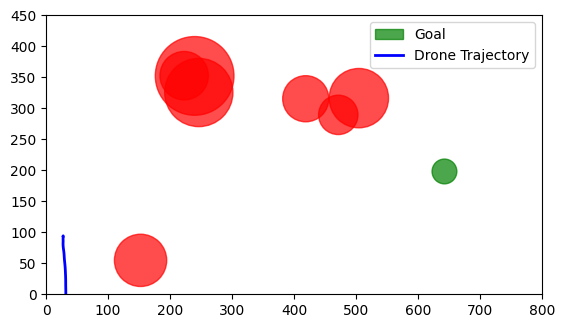

In [57]:
obs, _ = env.reset()
done = False
trajectory_x = []
trajectory_y = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    
    obs, reward, done, _, _ = env.step(action)
    
    trajectory_x.append(env.quad.state.x)
    trajectory_y.append(env.quad.state.y)
print(trajectory_x)

#Plotting
x,y=trajectory_x,trajectory_y
fig, ax = plt.subplots(1)
goal_circle = plt.Circle((env.goal[0], env.goal[1]), goalWidth, color="green", alpha=0.7, label="Goal")
ax.add_patch(goal_circle)

for obs in env.obstacles:
    circle = plt.Circle((obs.c[0], obs.c[1]), obs.r, color="red", alpha=0.7)
    ax.add_patch(circle)
ax.set_aspect('equal',adjustable='box')
ax.set_ylim(floor,cieling)
ax.set_xlim(0,XLim)
ax.plot(x, y, 'b-', linewidth=2, label='Drone Trajectory')
plt.legend()
plt.show()

